# Star Schema Modelling

## Break a dbt star schema on purpose, and see which tests notice

**Standalone notebook.** It generates a source system, builds the warehouse with
the same SQL the repo's dbt project uses, and breaks it 13 ways. It imports
nothing from the project package and writes nothing to disk. The warehouse runs
in an in-memory DuckDB, and a small resolver stands in for dbt (it fills in
`ref()` and `source()`, builds models in dependency order, and runs each test
query).

### What you will see

1. A source system with five planted traps, and a written-down answer key.
2. The correct model, scoring exactly 0.00 against that key.
3. The naive version of each trap, with the money it gets wrong.
4. A mutation matrix. Thirteen plausible edits to the model, every test run
   against each, and a record of which test fires. Some breaks are caught by the
   generic tests, some only by a singular business rule, some only by a test added
   after the first matrix, and one by nothing.

### Before you run

Colab and Kaggle already have pandas and matplotlib. You need one install.

```bash
pip install duckdb
```

About a minute top to bottom, 6 charts. Every code cell opens with a header that
says what it consumes and what it leaves behind, so you can start anywhere.

In [1]:
# ============================================================================
# 0.1  Imports and chart styling
# ----------------------------------------------------------------------------
# In   : nothing
# Out  : palette, style() helper, usd()
# Note : One palette for every chart. Nothing here touches the data.
# ============================================================================
import json
import re
import warnings
from decimal import Decimal

import duckdb
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.width", 170, "display.max_columns", 30, "display.max_colwidth", 80)

# Validated categorical slots; the first three are colourblind-safe on every pair.
BLUE, ORANGE, AQUA, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984"
SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#b8b7b2"

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": MUTED,
    "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.labelcolor": INK2, "axes.titlecolor": INK, "axes.titlesize": 12,
    "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.titlepad": 12,
    "text.color": INK, "xtick.color": INK2, "ytick.color": INK2,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "axes.labelsize": 10,
    "grid.color": "#e8e7e3", "grid.linewidth": 0.8, "legend.frameon": False,
    "legend.fontsize": 9, "figure.dpi": 110, "font.size": 10,
})


def style(ax, title=None, xlabel=None, ylabel=None, grid="y"):
    if title:
        ax.set_title(title)
    ax.set_xlabel(xlabel or "")
    ax.set_ylabel(ylabel or "")
    if grid:
        ax.grid(axis=grid, alpha=0.9, zorder=0)
        ax.set_axisbelow(True)
    return ax


def usd(x):
    return f"{Decimal(str(x)):,.2f}"


print("ready")

ready


## 1. The source system and its answer key

An online store exports four tables from its order system. The export has five
problems planted at known sizes, and each one is a place a star schema goes wrong.

| # | Planted problem | What a naive model does |
|---|---|---|
| 1 | Customers move region during the period | Joins the fact to the customer's *current* region, so old orders land in the wrong region |
| 2 | Shipping is charged per order | Puts it on the line-level fact and double counts it |
| 3 | An upstream retry re-sent chunks of the order lines file | Counts those lines twice |
| 4 | Some customers were synced after their first order | An inner join on the validity window silently drops those orders |
| 5 | Some orders are stamped on the exact second a region changed | An inclusive window join matches two versions and fans out |

The generator also writes the true revenue by day, region and category from its
own event history, in `TRUE_REVENUE`. The warehouse build never reads it.

In [2]:
# ============================================================================
# 1.1  Generate the source system and write down the answer key
# ----------------------------------------------------------------------------
# In   : nothing
# Out  : CONFIG, build_world(), world, TRUE_REVENUE, TRUE_SHIPPING, TRUE_LEDGER
# Note : build_world() is the repo's generator, copied in unchanged. The
#        TRUE_ names hold what really happened. Nothing that builds the
#        warehouse reads them.
# ============================================================================
CONFIG = {'data': {'seed': 42,
          'n_customers': 1500,
          'n_products': 400,
          'n_orders': 12000,
          'start_date': '2026-01-01',
          'n_days': 181,
          'regions': ['North', 'South', 'East', 'West', 'Central'],
          'categories': ['Electronics', 'Home', 'Garden', 'Sports', 'Books', 'Toys'],
          'lines_per_order_weights': [28, 30, 20, 12, 6, 4],
          'quantity_weights': [60, 25, 10, 5],
          'price_cents_min': 499,
          'price_cents_max': 19999,
          'discount_line_share_pct': 15,
          'discount_pcts': [5, 10, 20],
          'shipping_cents': [0, 399, 599, 799, 1299],
          'shipping_weights': [20, 30, 25, 15, 10],
          'status_values': ['processing', 'shipped', 'delivered'],
          'status_weights': [5, 15, 80]},
 'traps': {'relocate_once_share': 0.2,
           'relocate_twice_share': 0.05,
           'first_move_earliest_day': 15,
           'second_move_min_gap_days': 20,
           'late_customer_share': 0.04,
           'late_first_row_min_day': 30,
           'late_first_row_max_day': 120,
           'boundary_orders': 60,
           'resend_share': 0.02,
           'resend_chunk_min': 10,
           'resend_chunk_max': 50,
           'product_correction_share': 0.03},
 'showcase': {'customer_id': 1,
              'name': 'Ada Quinn',
              'region_from': 'North',
              'region_to': 'West',
              'moved_at': '2026-03-15 12:00:00',
              'orders_before': 4,
              'orders_after': 4},
 'paths': {'raw_dir': 'data/raw',
           'key_dir': 'data/answer_key',
           'artifacts': 'artifacts',
           'dbt_project': 'warehouse'}}

import datetime as dt
import random

FIRST_NAMES = ["Asha", "Ben", "Chen", "Dara", "Eli", "Farah", "Gus", "Hana", "Ivo",
               "Jin", "Kofi", "Lena", "Mateo", "Nia", "Omar", "Pia", "Quentin",
               "Rosa", "Sven", "Tara", "Uma", "Viktor", "Wen", "Xavi", "Yara", "Zane"]
LAST_NAMES = ["Adams", "Bose", "Cruz", "Diaz", "Evans", "Fox", "Gray", "Hale",
              "Iyer", "Jones", "Khan", "Lopez", "Mehta", "Nunez", "Okoye", "Park",
              "Reyes", "Singh", "Tran", "Usman", "Vega", "Wu", "Young", "Zhou"]
ADJECTIVES = ["Compact", "Classic", "Deluxe", "Eco", "Pro", "Smart", "Sturdy", "Lite"]
NOUNS = ["Lamp", "Kettle", "Racket", "Novel", "Drone", "Planter", "Puzzle", "Speaker",
         "Mat", "Bottle", "Tent", "Cable"]

CUSTOMER_HEADER = ["customer_id", "name", "email", "region", "updated_at"]
ORDER_HEADER = ["order_id", "customer_id", "order_ts", "status", "shipping_cost"]
LINE_HEADER = ["order_id", "line_no", "product_id", "quantity", "unit_price", "discount"]
PRODUCT_HEADER = ["product_id", "name", "category"]
CORRECTION_HEADER = ["product_id", "category", "corrected_at"]

FIRST_ORDER_ID = 100001


def money(cents):
    return f"{cents // 100}.{cents % 100:02d}"


def stamp(t):
    return t.strftime("%Y-%m-%d %H:%M:%S")


def _region_at(history, ts):
    """Region in force at ts. history[0] is the first known region and applies to
    every earlier time, even when the source stamped that row late."""
    region = history[0][1]
    for changed_at, new_region in history[1:]:
        if changed_at <= ts:
            region = new_region
    return region


def _build_customers(cfg, rng, start):
    d, t, sc = cfg["data"], cfg["traps"], cfg["showcase"]
    n, horizon = d["n_customers"], d["n_days"] * 86400
    ids = list(range(1, n + 1))
    others = [c for c in ids if c != sc["customer_id"]]
    rng.shuffle(others)
    n_late = round(t["late_customer_share"] * n)
    n_twice = round(t["relocate_twice_share"] * n)
    n_once = round(t["relocate_once_share"] * n) - 1   # the showcase customer is one mover
    late = set(others[:n_late])
    twice = set(others[n_late:n_late + n_twice])
    once = set(others[n_late + n_twice:n_late + n_twice + n_once])

    histories, names = {}, {}
    for cid in ids:
        names[cid] = f"{rng.choice(FIRST_NAMES)} {rng.choice(LAST_NAMES)}"
        region = rng.choice(d["regions"])
        if cid == sc["customer_id"]:
            names[cid] = sc["name"]
            signup = start - dt.timedelta(days=30)
            moved_at = dt.datetime.fromisoformat(sc["moved_at"])
            histories[cid] = [(signup, sc["region_from"]), (moved_at, sc["region_to"])]
            continue
        if cid in late:
            first = start + dt.timedelta(
                seconds=rng.randrange(t["late_first_row_min_day"] * 86400,
                                      t["late_first_row_max_day"] * 86400))
        else:
            first = start - dt.timedelta(seconds=rng.randrange(86400, 60 * 86400))
        history = [(first, region)]
        if cid in once or cid in twice:
            move = start + dt.timedelta(
                seconds=rng.randrange(t["first_move_earliest_day"] * 86400,
                                      horizon - 30 * 86400))
            region = rng.choice([r for r in d["regions"] if r != region])
            history.append((move, region))
            if cid in twice:
                room = horizon - 5 * 86400 - int((move - start).total_seconds())
                move2 = move + dt.timedelta(
                    seconds=rng.randrange(t["second_move_min_gap_days"] * 86400, room))
                region = rng.choice([r for r in d["regions"] if r != region])
                history.append((move2, region))
        histories[cid] = history
    return ids, names, histories, late, once | {sc["customer_id"]}, twice


def _build_products(cfg, rng, start):
    d, t = cfg["data"], cfg["traps"]
    products = []
    for pid in range(1, d["n_products"] + 1):
        category = rng.choice(d["categories"])
        products.append({
            "product_id": pid,
            "name": f"{rng.choice(ADJECTIVES)} {rng.choice(NOUNS)} {pid}",
            "category": category,           # the correct category
            "listed_category": category,    # what products.csv says
            "price": rng.randrange(d["price_cents_min"], d["price_cents_max"]),
        })
    corrections = []
    for idx in sorted(rng.sample(range(len(products)), round(t["product_correction_share"] * len(products)))):
        p = products[idx]
        p["listed_category"] = rng.choice([c for c in d["categories"] if c != p["category"]])
        corrections.append([str(p["product_id"]), p["category"], stamp(start)])
    return products, corrections


def _build_orders(cfg, rng, start, histories, late, products, moves):
    d, t, sc = cfg["data"], cfg["traps"], cfg["showcase"]
    horizon = d["n_days"] * 86400
    sc_id = sc["customer_id"]
    moved_at = dt.datetime.fromisoformat(sc["moved_at"])
    before_span = int((moved_at - start).total_seconds())

    draws = []   # (customer_id, order_ts, kind)
    n_random = d["n_orders"] - t["boundary_orders"] - sc["orders_before"] - sc["orders_after"]
    for _ in range(n_random):
        draws.append((rng.randint(2, d["n_customers"]),
                      start + dt.timedelta(seconds=rng.randrange(horizon)), "random"))
    movers = [m for m in moves if m[0] != sc_id]
    for cid, changed_at in rng.sample(movers, t["boundary_orders"]):
        draws.append((cid, changed_at, "boundary"))
    for _ in range(sc["orders_before"]):
        draws.append((sc_id, start + dt.timedelta(seconds=rng.randrange(before_span)), "showcase"))
    for _ in range(sc["orders_after"]):
        draws.append((sc_id, moved_at + dt.timedelta(
            seconds=1 + rng.randrange(horizon - before_span - 1)), "showcase"))
    draws.sort(key=lambda x: (x[1], x[0], x[2]))

    orders = []
    for i, (cid, ts, kind) in enumerate(draws):
        n_lines = rng.choices(range(1, len(d["lines_per_order_weights"]) + 1),
                              d["lines_per_order_weights"])[0]
        lines = []
        for line_no, p_idx in enumerate(rng.sample(range(len(products)), n_lines), start=1):
            p = products[p_idx]
            qty = rng.choices([1, 2, 3, 4], d["quantity_weights"])[0]
            discount = 0
            if rng.randrange(100) < d["discount_line_share_pct"]:
                discount = qty * p["price"] * rng.choice(d["discount_pcts"]) // 100
            lines.append({"line_no": line_no, "product": p, "qty": qty, "discount": discount})
        orders.append({
            "order_id": FIRST_ORDER_ID + i, "customer_id": cid, "ts": ts, "kind": kind,
            "status": rng.choices(d["status_values"], d["status_weights"])[0],
            "shipping": rng.choices(d["shipping_cents"], d["shipping_weights"])[0],
            "lines": lines,
            "region": _region_at(histories[cid], ts),
        })
    return orders


def _resend_chunks(cfg, rng, n_lines):
    """Pick non-overlapping chunks of consecutive line rows that the upstream
    retry sends a second time, immediately after the first send."""
    t = cfg["traps"]
    target = round(t["resend_share"] * n_lines)
    covered, chunks, total = set(), [], 0
    while total < target:
        size = min(rng.randrange(t["resend_chunk_min"], t["resend_chunk_max"] + 1), target - total)
        first = rng.randrange(0, n_lines - size)
        span = range(first, first + size)
        if covered.intersection(span):
            continue
        covered.update(span)
        chunks.append((first, first + size))
        total += size
    return sorted(chunks)


def build_world(cfg):
    """Return {"raw": {table: (header, rows)}, "TRUE_REVENUE", "TRUE_SHIPPING", "TRUE_LEDGER"}.
    Raw rows are lists of strings, exactly what lands in the CSV files."""
    d = cfg["data"]
    rng = random.Random(d["seed"])
    start = dt.datetime.fromisoformat(d["start_date"])

    ids, names, histories, late, once, twice = _build_customers(cfg, rng, start)
    products, corrections = _build_products(cfg, rng, start)
    moves = sorted((cid, changed_at) for cid, h in histories.items() for changed_at, _ in h[1:])
    orders = _build_orders(cfg, rng, start, histories, late, products, moves)

    # ---- raw tables, as the OLTP export would write them ----
    changes = []
    for cid in ids:
        for changed_at, region in histories[cid]:
            changes.append([str(cid), names[cid], f"customer{cid}@example.com", region, stamp(changed_at)])
    changes.sort(key=lambda r: (r[4], int(r[0])))

    order_rows = [[str(o["order_id"]), str(o["customer_id"]), stamp(o["ts"]), o["status"],
                   money(o["shipping"])] for o in orders]
    line_rows, line_cents = [], []
    for o in orders:
        for ln in o["lines"]:
            p = ln["product"]
            line_rows.append([str(o["order_id"]), str(ln["line_no"]), str(p["product_id"]),
                              str(ln["qty"]), money(p["price"]), money(ln["discount"])])
            line_cents.append(ln["qty"] * p["price"] - ln["discount"])
    chunks = _resend_chunks(cfg, rng, len(line_rows))
    sent, ends = [], {last - 1: first for first, last in chunks}
    for i, row in enumerate(line_rows):
        sent.append(row)
        if i in ends:
            sent.extend(list(r) for r in line_rows[ends[i]:i + 1])
    product_rows = [[str(p["product_id"]), p["name"], p["listed_category"]] for p in products]

    # ---- the answer key, computed from the events, not from the raw tables ----
    by_cell, by_ship = {}, {}
    ledger = {k: 0 for k in (
        "late_orders", "late_order_lines", "late_revenue_cents",
        "boundary_order_lines", "boundary_revenue_cents", "boundary_shipping_cents",
        "relocated_orders", "relocated_lines", "relocated_revenue_cents",
        "shipping_excess_cents", "corrected_product_revenue_cents")}
    region_shift, resent_revenue = {}, 0
    current = {cid: h[-1][1] for cid, h in histories.items()}
    corrected_ids = {int(r[0]) for r in corrections}
    revenue_of = {}
    for o in orders:
        day = o["ts"].strftime("%Y-%m-%d")
        ship = by_ship.setdefault((day, o["region"]), [0, 0])
        ship[0] += 1
        ship[1] += o["shipping"]
        ledger["shipping_excess_cents"] += o["shipping"] * (len(o["lines"]) - 1)
        order_rev = 0
        for ln in o["lines"]:
            p = ln["product"]
            rev = ln["qty"] * p["price"] - ln["discount"]
            order_rev += rev
            cell = by_cell.setdefault((day, o["region"], p["category"]), [0, 0, 0])
            cell[0] += ln["qty"]
            cell[1] += 1
            cell[2] += rev
            if p["product_id"] in corrected_ids:
                ledger["corrected_product_revenue_cents"] += rev
        revenue_of[o["order_id"]] = order_rev
        if o["kind"] == "boundary":
            ledger["boundary_order_lines"] += len(o["lines"])
            ledger["boundary_revenue_cents"] += order_rev
            ledger["boundary_shipping_cents"] += o["shipping"]
        if o["customer_id"] in late and o["ts"] < histories[o["customer_id"]][0][0]:
            ledger["late_orders"] += 1
            ledger["late_order_lines"] += len(o["lines"])
            ledger["late_revenue_cents"] += order_rev
        if o["region"] != current[o["customer_id"]]:
            ledger["relocated_orders"] += 1
            ledger["relocated_lines"] += len(o["lines"])
            ledger["relocated_revenue_cents"] += order_rev
            region_shift[o["region"]] = region_shift.get(o["region"], 0) - order_rev
            region_shift[current[o["customer_id"]]] = region_shift.get(current[o["customer_id"]], 0) + order_rev
    for first, last in chunks:
        resent_revenue += sum(line_cents[first:last])

    sc = cfg["showcase"]
    showcase = [{
        "order_id": o["order_id"], "order_ts": stamp(o["ts"]),
        "amount_cents": revenue_of[o["order_id"]],
        "true_region": o["region"], "current_region": current[o["customer_id"]]}
        for o in orders if o["customer_id"] == sc["customer_id"]]

    ledger.update({
        "n_customers": len(ids), "n_products": len(products), "n_orders": len(orders),
        "n_lines": len(line_rows), "n_line_rows_sent": len(sent),
        "n_customer_change_rows": len(changes), "n_product_corrections": len(corrections),
        "customers_relocating_once": len(once), "customers_relocating_twice": len(twice),
        "move_events": len(moves), "late_customers": len(late),
        "boundary_orders": cfg["traps"]["boundary_orders"],
        "resent_rows": len(sent) - len(line_rows), "resent_chunks": len(chunks),
        "resent_revenue_cents": resent_revenue,
        "true_line_revenue_cents": sum(c[2] for c in by_cell.values()),
        "true_shipping_cents": sum(v[1] for v in by_ship.values()),
        "relocation_region_shift_cents": dict(sorted(region_shift.items())),
        "showcase_orders": showcase,
    })
    true_revenue = [[day, region, cat, v[0], v[1], v[2]] for (day, region, cat), v in sorted(by_cell.items())]
    true_shipping = [[day, region, v[0], v[1]] for (day, region), v in sorted(by_ship.items())]
    return {
        "raw": {
            "customer_changes": (CUSTOMER_HEADER, changes),
            "orders": (ORDER_HEADER, order_rows),
            "order_lines": (LINE_HEADER, sent),
            "products": (PRODUCT_HEADER, product_rows),
            "product_corrections": (CORRECTION_HEADER, corrections),
        },
        "TRUE_REVENUE": true_revenue,
        "TRUE_SHIPPING": true_shipping,
        "TRUE_LEDGER": ledger,
    }

world = build_world(CONFIG)
TRUE_REVENUE, TRUE_SHIPPING, TRUE_LEDGER = world["TRUE_REVENUE"], world["TRUE_SHIPPING"], world["TRUE_LEDGER"]

print("raw rows:", {t: len(rows) for t, (_, rows) in world["raw"].items()})
planted = {k: TRUE_LEDGER[k] for k in (
    "customers_relocating_once", "customers_relocating_twice", "relocated_orders",
    "resent_rows", "late_customers", "late_orders", "boundary_orders")}
print("planted:", planted)

raw rows: {'customer_changes': 1950, 'orders': 12000, 'order_lines': 30500, 'products': 400, 'product_corrections': 12}
planted: {'customers_relocating_once': 300, 'customers_relocating_twice': 75, 'relocated_orders': 1513, 'resent_rows': 598, 'late_customers': 60, 'late_orders': 182, 'boundary_orders': 60}


In [3]:
# ============================================================================
# 1.2  Load the raw tables as text
# ----------------------------------------------------------------------------
# In   : world
# Out  : load_raw(), the raw schema in DuckDB
# Note : Every raw column is a string, so staging is the one place types are
#        decided.
# ============================================================================
def load_raw(con):
    """Every raw column is a string, exactly as the CSV export would hold it."""
    con.execute("create schema if not exists raw")
    for table, (header, rows) in world["raw"].items():
        frame = pd.DataFrame(rows, columns=header, dtype="string")
        con.register("raw_frame", frame)
        con.execute(f"create or replace table raw.{table} as select * from raw_frame")
        con.unregister("raw_frame")


print("loader ready")

loader ready


## 2. The scorer

`score_revenue` and `score_shipping` compare a built report to the answer key in
exact Decimal arithmetic. There is no tolerance, because a tolerance would hide
the float mutation later. `classify` and `is_silent` read a build result and say
which tier of test noticed a break.

In [4]:
# ============================================================================
# 2.1  The scorer and the verdict helpers
# ----------------------------------------------------------------------------
# In   : nothing
# Out  : score_revenue(), score_shipping(), classify(), is_silent()
# Note : Exact Decimal arithmetic. A tolerance would hide the float
#        mutation.
# ============================================================================
from decimal import Decimal


def cents_to_decimal(cents):
    return Decimal(cents).scaleb(-2)


def _label(value):
    return "(null)" if value is None else str(value)


def _summarise(true_total, report_total, diffs, extra):
    abs_error = sum((abs(d) for d in diffs.values()), Decimal(0))
    return {
        "true_total": true_total, "report_total": report_total,
        "net_error": report_total - true_total, "abs_error": abs_error,
        "pct_of_true": (abs_error / true_total * 100) if true_total else Decimal(0),
        **extra,
    }


def _group_net(rows_by_cell, position):
    out = {}
    for cell, value in rows_by_cell.items():
        out[cell[position]] = out.get(cell[position], Decimal(0)) + value
    return out


def _worst(net_by_group):
    if not net_by_group:
        return ("-", Decimal(0))
    name = max(sorted(net_by_group), key=lambda k: abs(net_by_group[k]))
    return (name, net_by_group[name])


def score_revenue(report_rows, true_rows):
    """report_rows: (order_date, region, category, units, order_lines, line_revenue).
    true_rows: [order_date, region, category, units, order_lines, revenue_cents]."""
    true = {(r[0], r[1], r[2]): (r[3], r[4], cents_to_decimal(r[5])) for r in true_rows}
    got = {}
    for day, region, cat, units, lines, revenue in report_rows:
        key = (str(day), _label(region), _label(cat))
        u, n, rev = got.get(key, (0, 0, Decimal(0)))
        got[key] = (u + int(units), n + int(lines), rev + Decimal(str(revenue)))
    keys = sorted(set(true) | set(got))
    zero = (0, 0, Decimal(0))
    diffs = {k: got.get(k, zero)[2] - true.get(k, zero)[2] for k in keys}
    wrong = [k for k in keys if got.get(k, zero) != true.get(k, zero)]
    by_region, by_category = _group_net(diffs, 1), _group_net(diffs, 2)
    summary = _summarise(
        sum((v[2] for v in true.values()), Decimal(0)),
        sum((v[2] for v in got.values()), Decimal(0)), diffs,
        {"cells_true": len(true), "cells_wrong": len(wrong),
         "cells_missing": len(set(true) - set(got)), "cells_extra": len(set(got) - set(true)),
         "units_error": sum(v[0] for v in got.values()) - sum(v[0] for v in true.values()),
         "lines_error": sum(v[1] for v in got.values()) - sum(v[1] for v in true.values()),
         "by_region": by_region, "by_category": by_category,
         "true_by_region": _group_net({k: v[2] for k, v in true.items()}, 1),
         "report_by_region": _group_net({k: v[2] for k, v in got.items()}, 1),
         "worst_region": _worst(by_region), "worst_category": _worst(by_category)})
    summary["exact"] = not wrong
    return summary


def score_shipping(report_rows, true_rows):
    """report_rows: (order_date, region, orders, shipping_revenue).
    true_rows: [order_date, region, orders, shipping_cents]."""
    true = {(r[0], r[1]): (r[2], cents_to_decimal(r[3])) for r in true_rows}
    got = {}
    for day, region, orders, shipping in report_rows:
        key = (str(day), _label(region))
        n, amount = got.get(key, (0, Decimal(0)))
        got[key] = (n + int(orders), amount + Decimal(str(shipping)))
    keys = sorted(set(true) | set(got))
    zero = (0, Decimal(0))
    diffs = {k: got.get(k, zero)[1] - true.get(k, zero)[1] for k in keys}
    wrong = [k for k in keys if got.get(k, zero) != true.get(k, zero)]
    by_region = _group_net(diffs, 1)
    summary = _summarise(
        sum((v[1] for v in true.values()), Decimal(0)),
        sum((v[1] for v in got.values()), Decimal(0)), diffs,
        {"cells_true": len(true), "cells_wrong": len(wrong),
         "by_region": by_region, "worst_region": _worst(by_region)})
    summary["exact"] = not wrong
    return summary


TIERS = ["generic", "singular", "added"]


def tiers_firing(result):
    out = {t: [] for t in TIERS}
    for t in result["tests"]:
        if t["status"] != "pass":
            out[t["tier"]].append(t["label"])
    return out


def classify(result):
    """The first line of defence that notices the break."""
    if not result["run_ok"]:
        return "build error"
    fired = tiers_firing(result)
    if fired["generic"]:
        return "generic"
    if fired["singular"]:
        return "singular only"
    if fired["added"]:
        return "added only"
    return "nothing"


def is_silent(result):
    """True when the typical suite (generic plus singular) passes and the answer is still wrong."""
    fired = tiers_firing(result)
    wrong = not (result["score"]["revenue"]["exact"] and result["score"]["shipping"]["exact"])
    return wrong and not fired["generic"] and not fired["singular"]

## 3. The dbt project, as text

These are the repo's model and test files, read at build time and pasted in. The
`{{ ref() }}` and `{{ source() }}` calls are still in them. Staging only casts,
renames and dedups. `dim_customer` is Type 2 with an exclusive `valid_to`. There
are two facts at two grains, and shipping lives only on the order grain fact.

In [5]:
# ============================================================================
# 3.1  The staging models, as written in the repo
# ----------------------------------------------------------------------------
# In   : nothing
# Out  : STAGING (name -> SQL with ref() and source() still in it)
# Note : Staging only casts, renames and dedups.
# ============================================================================
STAGING = {
"models/staging/stg_customer_changes.sql": """\
-- Staging casts and renames. It does not filter, join or correct anything.
select
    cast(customer_id as integer) as customer_id,
    name,
    email,
    region,
    cast(updated_at as timestamp) as updated_at
from {{ source('raw', 'customer_changes') }}
""",
"models/staging/stg_order_lines.sql": """\
-- The upstream retry re-sent chunks of this file, so the same (order_id, line_no)
-- can arrive twice. The natural key is the grain, so staging keeps one copy.
with typed as (
    select
        cast(order_id as integer) as order_id,
        cast(line_no as integer) as line_no,
        cast(product_id as integer) as product_id,
        cast(quantity as integer) as quantity,
        cast(unit_price as decimal(12, 2)) as unit_price,
        cast(discount as decimal(12, 2)) as discount
    from {{ source('raw', 'order_lines') }}
),

ranked as (
    select
        *,
        row_number() over (partition by order_id, line_no order by product_id) as copy_rank
    from typed
)

select
    order_id,
    line_no,
    product_id,
    quantity,
    unit_price,
    discount
from ranked
where copy_rank = 1
""",
"models/staging/stg_orders.sql": """\
select
    cast(order_id as integer) as order_id,
    cast(customer_id as integer) as customer_id,
    cast(order_ts as timestamp) as order_ts,
    status,
    cast(shipping_cost as decimal(12, 2)) as shipping_cost
from {{ source('raw', 'orders') }}
""",
"models/staging/stg_product_corrections.sql": """\
select
    cast(product_id as integer) as product_id,
    category as corrected_category,
    cast(corrected_at as timestamp) as corrected_at
from {{ source('raw', 'product_corrections') }}
""",
"models/staging/stg_products.sql": """\
select
    cast(product_id as integer) as product_id,
    name,
    category
from {{ source('raw', 'products') }}
""",
}

In [6]:
# ============================================================================
# 3.2  The mart models, as written in the repo
# ----------------------------------------------------------------------------
# In   : nothing
# Out  : MARTS (name -> SQL)
# Note : Two dimensions, two facts at two grains, two reports.
# ============================================================================
MARTS = {
"models/marts/dim_customer.sql": """\
-- Type 2 customer dimension. One row per version the source reported.
--
-- valid_from is inclusive and valid_to is EXCLUSIVE, and valid_to is the next
-- version's valid_from. Facts join with  ts >= valid_from and ts < valid_to,
-- so an order stamped exactly on a change lands in exactly one version.
--
-- Version 1 is back-dated to 1900-01-01. Some customers were synced after their
-- first order, so the source's first timestamp is later than the order. The
-- order proves the customer existed, and the first known region is the best
-- evidence for where they were, so version 1 covers all earlier time. An
-- "unknown member" row would drop the region from revenue that has one.
with versions as (
    select
        customer_id,
        name,
        email,
        region,
        updated_at,
        row_number() over (partition by customer_id order by updated_at) as version_no,
        lead(updated_at) over (partition by customer_id order by updated_at) as next_updated_at
    from {{ ref('stg_customer_changes') }}
)

select
    row_number() over (order by customer_id, updated_at) as customer_sk,
    customer_id,
    name,
    email,
    region,
    version_no,
    case when version_no = 1 then cast('1900-01-01' as timestamp) else updated_at end as valid_from,
    coalesce(next_updated_at, cast('9999-12-31' as timestamp)) as valid_to,
    next_updated_at is null as is_current
from versions
""",
"models/marts/dim_product.sql": """\
-- Type 1 product dimension. A category correction fixes a data entry error, so
-- it replaces the old value and restates history. Nobody wants last quarter's
-- revenue left under a category that was never right.
select
    row_number() over (order by p.product_id) as product_sk,
    p.product_id,
    p.name,
    coalesce(c.corrected_category, p.category) as category
from {{ ref('stg_products') }} as p
left join {{ ref('stg_product_corrections') }} as c on c.product_id = p.product_id
""",
"models/marts/fct_order.sql": """\
-- Grain: one row per order. Shipping is charged once per order, so it lives
-- here and nowhere else. Put it on the line fact and every multi-line order
-- counts it once per line.
select
    o.order_id,
    c.customer_sk,
    o.order_ts,
    cast(o.order_ts as date) as order_date,
    o.status,
    o.shipping_cost
from {{ ref('stg_orders') }} as o
left join {{ ref('dim_customer') }} as c
    on c.customer_id = o.customer_id
    and o.order_ts >= c.valid_from
    and o.order_ts < c.valid_to
""",
"models/marts/fct_order_line.sql": """\
-- Grain: one row per order line, (order_id, line_no).
-- customer_sk is the customer version in force when the order was placed, found
-- by the validity window, never by is_current. LEFT join so a missing version
-- shows up as a null that the not_null test catches, not as a vanished row.
select
    l.order_id,
    l.line_no,
    c.customer_sk,
    p.product_sk,
    o.order_ts,
    cast(o.order_ts as date) as order_date,
    l.quantity,
    l.unit_price,
    l.discount,
    l.quantity * l.unit_price - l.discount as line_revenue
from {{ ref('stg_order_lines') }} as l
inner join {{ ref('stg_orders') }} as o on o.order_id = l.order_id
left join {{ ref('dim_customer') }} as c
    on c.customer_id = o.customer_id
    and o.order_ts >= c.valid_from
    and o.order_ts < c.valid_to
left join {{ ref('dim_product') }} as p on p.product_id = l.product_id
""",
"models/marts/rpt_revenue_by_region_category_day.sql": """\
-- Revenue by the region the customer was in when they ordered.
select
    f.order_date,
    c.region,
    p.category,
    sum(f.quantity) as units,
    count(*) as order_lines,
    sum(f.line_revenue) as line_revenue
from {{ ref('fct_order_line') }} as f
left join {{ ref('dim_customer') }} as c on c.customer_sk = f.customer_sk
left join {{ ref('dim_product') }} as p on p.product_sk = f.product_sk
group by 1, 2, 3
""",
"models/marts/rpt_shipping_by_region_day.sql": """\
-- Shipping charged, by the customer's region at order time. Read from the
-- order grain fact, where one row is one order.
select
    f.order_date,
    c.region,
    count(*) as orders,
    sum(f.shipping_cost) as shipping_revenue
from {{ ref('fct_order') }} as f
left join {{ ref('dim_customer') }} as c on c.customer_sk = f.customer_sk
group by 1, 2
""",
}

In [7]:
# ============================================================================
# 3.3  The tests, as written in the repo
# ----------------------------------------------------------------------------
# In   : nothing
# Out  : SINGULAR, ADDED, MACROS, SCHEMA_TESTS
# Note : Generic tests come from schema.yml. Singular and added tests are
#        plain SQL files.
# ============================================================================
SINGULAR = {
"assert_fact_inside_customer_window": """\
-- The business rule behind the Type 2 dimension. Whatever customer version a
-- fact points at must have been valid when the order was placed. No generic
-- test can say this, because it compares a fact column to a dimension window.
select 'fct_order_line' as fact, f.order_id, f.line_no
from {{ ref('fct_order_line') }} as f
inner join {{ ref('dim_customer') }} as c on c.customer_sk = f.customer_sk
where not (f.order_ts >= c.valid_from and f.order_ts < c.valid_to)

union all

select 'fct_order' as fact, f.order_id, null as line_no
from {{ ref('fct_order') }} as f
inner join {{ ref('dim_customer') }} as c on c.customer_sk = f.customer_sk
where not (f.order_ts >= c.valid_from and f.order_ts < c.valid_to)
""",
"assert_line_revenue_reconciles_to_staging": """\
-- Revenue on the line fact must equal revenue recomputed from staging. The
-- formula is written out again here on purpose, so a change to the model's
-- formula is not copied into its own check.
select
    f.revenue as fact_revenue,
    s.revenue as staging_revenue
from (select sum(line_revenue) as revenue from {{ ref('fct_order_line') }}) as f
cross join (
    select sum(quantity * unit_price - discount) as revenue from {{ ref('stg_order_lines') }}
) as s
where f.revenue is distinct from s.revenue
""",
"assert_one_current_row_per_customer": """\
-- Every customer has exactly one current version. Zero means a customer who
-- vanishes from "now" reports, two means they are counted twice.
select
    customer_id,
    sum(case when is_current then 1 else 0 end) as current_rows
from {{ ref('dim_customer') }}
group by customer_id
having sum(case when is_current then 1 else 0 end) <> 1
""",
"assert_shipping_reconciles_to_staging": """\
-- Shipping on the order fact must equal shipping in staging.
select
    f.shipping as fact_shipping,
    s.shipping as staging_shipping
from (select sum(shipping_cost) as shipping from {{ ref('fct_order') }}) as f
cross join (select sum(shipping_cost) as shipping from {{ ref('stg_orders') }}) as s
where f.shipping is distinct from s.shipping
""",
}

ADDED = {
"assert_dim_customer_keeps_every_source_version": """\
{{ config(tags=['added']) }}
-- Added after the matrix showed a break nobody caught. A Type 2 dimension keeps
-- one row for every version the source reported. A dimension overwritten in
-- place still has one current row and windows that contain every order, so only
-- a count against the source shows that history is gone.
select d.n as dim_rows, s.n as source_versions
from (select count(*) as n from {{ ref('dim_customer') }}) as d
cross join (select count(*) as n from {{ ref('stg_customer_changes') }}) as s
where d.n <> s.n
""",
"assert_fact_row_counts_match_staging": """\
{{ config(tags=['added']) }}
-- Added after the matrix showed a break nobody caught. A fact with the right
-- grain has exactly one row for each staging row it describes. Fewer rows means
-- a join dropped some, more means a join fanned out or the grain changed.
select 'fct_order_line' as fact, f.n as fact_rows, s.n as staging_rows
from (select count(*) as n from {{ ref('fct_order_line') }}) as f
cross join (select count(*) as n from {{ ref('stg_order_lines') }}) as s
where f.n <> s.n

union all

select 'fct_order' as fact, f.n as fact_rows, s.n as staging_rows
from (select count(*) as n from {{ ref('fct_order') }}) as f
cross join (select count(*) as n from {{ ref('stg_orders') }}) as s
where f.n <> s.n
""",
"assert_product_corrections_applied": """\
{{ config(tags=['added']) }}
-- Added after the matrix showed a break nobody caught. Every category correction
-- from the source must be what dim_product holds.
select d.product_id, d.category as dim_category, c.corrected_category
from {{ ref('dim_product') }} as d
inner join {{ ref('stg_product_corrections') }} as c on c.product_id = d.product_id
where d.category <> c.corrected_category
""",
"assert_report_reconciles_to_facts": """\
{{ config(tags=['added']) }}
-- Added after the matrix showed a break nobody caught. A report must add up to
-- the fact it is built from. Both reports are checked against the fact of the
-- right grain, so shipping read from the line grain shows up here.
select 'line_revenue' as measure, r.total as report_total, f.total as fact_total
from (select sum(line_revenue) as total from {{ ref('rpt_revenue_by_region_category_day') }}) as r
cross join (select sum(line_revenue) as total from {{ ref('fct_order_line') }}) as f
where r.total is distinct from f.total

union all

select 'shipping_revenue' as measure, r.total as report_total, f.total as fact_total
from (select sum(shipping_revenue) as total from {{ ref('rpt_shipping_by_region_day') }}) as r
cross join (select sum(shipping_cost) as total from {{ ref('fct_order') }}) as f
where r.total is distinct from f.total
""",
"assert_staging_keeps_every_distinct_source_line": """\
{{ config(tags=['added']) }}
-- Added after the matrix showed a break nobody caught. Reconciling a fact to
-- staging proves nothing when staging itself is wrong. This test goes back to
-- the raw table and counts the distinct (order_id, line_no) keys it holds.
select s.n as staging_rows, r.n as distinct_source_lines
from (select count(*) as n from {{ ref('stg_order_lines') }}) as s
cross join (
    select count(*) as n
    from (select distinct order_id, line_no from {{ source('raw', 'order_lines') }})
) as r
where s.n <> r.n
""",
}

MACROS = {
"column_is_decimal": """\
-- Money must be DECIMAL. A float column passes every not_null, unique and
-- relationships test, so this checks the type itself.
select distinct typeof({{ column_name }}) as column_type
from {{ model }}
where typeof({{ column_name }}) not like 'DECIMAL%'""",
"unique_combination_of_columns": """\
-- The grain test. A fact's grain is a set of columns, and the test is that no
-- combination of them appears twice. Written here so the project needs no packages.
select
    {{ combination_of_columns | join(', ') }},
    count(*) as row_count
from {{ model }}
group by {{ combination_of_columns | join(', ') }}
having count(*) > 1""",
}

SCHEMA_TESTS = [{'name': 'unique_combination_of_columns',
  'model': 'dim_customer',
  'column': None,
  'args': {'combination_of_columns': ['customer_id', 'valid_from']},
  'tier': 'generic'},
 {'name': 'unique',
  'model': 'dim_customer',
  'column': 'customer_sk',
  'args': {},
  'tier': 'generic'},
 {'name': 'not_null',
  'model': 'dim_customer',
  'column': 'customer_sk',
  'args': {},
  'tier': 'generic'},
 {'name': 'not_null',
  'model': 'dim_customer',
  'column': 'customer_id',
  'args': {},
  'tier': 'generic'},
 {'name': 'not_null',
  'model': 'dim_customer',
  'column': 'region',
  'args': {},
  'tier': 'generic'},
 {'name': 'not_null',
  'model': 'dim_customer',
  'column': 'valid_from',
  'args': {},
  'tier': 'generic'},
 {'name': 'not_null',
  'model': 'dim_customer',
  'column': 'valid_to',
  'args': {},
  'tier': 'generic'},
 {'name': 'not_null',
  'model': 'dim_customer',
  'column': 'is_current',
  'args': {},
  'tier': 'generic'},
 {'name': 'accepted_values',
  'model': 'dim_customer',
  'column': 'is_current',
  'args': {'values': [True, False], 'quote': False},
  'tier': 'generic'},
 {'name': 'unique',
  'model': 'dim_product',
  'column': 'product_sk',
  'args': {},
  'tier': 'generic'},
 {'name': 'not_null',
  'model': 'dim_product',
  'column': 'product_sk',
  'args': {},
  'tier': 'generic'},
 {'name': 'unique',
  'model': 'dim_product',
  'column': 'product_id',
  'args': {},
  'tier': 'generic'},
 {'name': 'not_null',
  'model': 'dim_product',
  'column': 'product_id',
  'args': {},
  'tier': 'generic'},
 {'name': 'not_null',
  'model': 'dim_product',
  'column': 'category',
  'args': {},
  'tier': 'generic'},
 {'name': 'unique', 'model': 'fct_order', 'column': 'order_id', 'args': {}, 'tier': 'generic'},
 {'name': 'not_null',
  'model': 'fct_order',
  'column': 'order_id',
  'args': {},
  'tier': 'generic'},
 {'name': 'not_null',
  'model': 'fct_order',
  'column': 'customer_sk',
  'args': {},
  'tier': 'generic'},
 {'name': 'relationships',
  'model': 'fct_order',
  'column': 'customer_sk',
  'args': {'to': "ref('dim_customer')", 'field': 'customer_sk'},
  'tier': 'generic'},
 {'name': 'not_null',
  'model': 'fct_order',
  'column': 'shipping_cost',
  'args': {},
  'tier': 'generic'},
 {'name': 'column_is_decimal',
  'model': 'fct_order',
  'column': 'shipping_cost',
  'args': {},
  'tier': 'added'},
 {'name': 'unique_combination_of_columns',
  'model': 'fct_order_line',
  'column': None,
  'args': {'combination_of_columns': ['order_id', 'line_no']},
  'tier': 'generic'},
 {'name': 'not_null',
  'model': 'fct_order_line',
  'column': 'order_id',
  'args': {},
  'tier': 'generic'},
 {'name': 'relationships',
  'model': 'fct_order_line',
  'column': 'order_id',
  'args': {'to': "ref('fct_order')", 'field': 'order_id'},
  'tier': 'generic'},
 {'name': 'not_null',
  'model': 'fct_order_line',
  'column': 'customer_sk',
  'args': {},
  'tier': 'generic'},
 {'name': 'relationships',
  'model': 'fct_order_line',
  'column': 'customer_sk',
  'args': {'to': "ref('dim_customer')", 'field': 'customer_sk'},
  'tier': 'generic'},
 {'name': 'not_null',
  'model': 'fct_order_line',
  'column': 'product_sk',
  'args': {},
  'tier': 'generic'},
 {'name': 'relationships',
  'model': 'fct_order_line',
  'column': 'product_sk',
  'args': {'to': "ref('dim_product')", 'field': 'product_sk'},
  'tier': 'generic'},
 {'name': 'not_null',
  'model': 'fct_order_line',
  'column': 'line_revenue',
  'args': {},
  'tier': 'generic'},
 {'name': 'column_is_decimal',
  'model': 'fct_order_line',
  'column': 'line_revenue',
  'args': {},
  'tier': 'added'},
 {'name': 'unique_combination_of_columns',
  'model': 'rpt_revenue_by_region_category_day',
  'column': None,
  'args': {'combination_of_columns': ['order_date', 'region', 'category']},
  'tier': 'generic'},
 {'name': 'not_null',
  'model': 'rpt_revenue_by_region_category_day',
  'column': 'region',
  'args': {},
  'tier': 'generic'},
 {'name': 'not_null',
  'model': 'rpt_revenue_by_region_category_day',
  'column': 'category',
  'args': {},
  'tier': 'generic'},
 {'name': 'unique_combination_of_columns',
  'model': 'rpt_shipping_by_region_day',
  'column': None,
  'args': {'combination_of_columns': ['order_date', 'region']},
  'tier': 'generic'},
 {'name': 'not_null',
  'model': 'rpt_shipping_by_region_day',
  'column': 'region',
  'args': {},
  'tier': 'generic'},
 {'name': 'unique_combination_of_columns',
  'model': 'stg_customer_changes',
  'column': None,
  'args': {'combination_of_columns': ['customer_id', 'updated_at']},
  'tier': 'generic'},
 {'name': 'not_null',
  'model': 'stg_customer_changes',
  'column': 'customer_id',
  'args': {},
  'tier': 'generic'},
 {'name': 'not_null',
  'model': 'stg_customer_changes',
  'column': 'region',
  'args': {},
  'tier': 'generic'},
 {'name': 'accepted_values',
  'model': 'stg_customer_changes',
  'column': 'region',
  'args': {'values': ['North', 'South', 'East', 'West', 'Central']},
  'tier': 'generic'},
 {'name': 'not_null',
  'model': 'stg_customer_changes',
  'column': 'updated_at',
  'args': {},
  'tier': 'generic'},
 {'name': 'unique', 'model': 'stg_orders', 'column': 'order_id', 'args': {}, 'tier': 'generic'},
 {'name': 'not_null',
  'model': 'stg_orders',
  'column': 'order_id',
  'args': {},
  'tier': 'generic'},
 {'name': 'not_null',
  'model': 'stg_orders',
  'column': 'customer_id',
  'args': {},
  'tier': 'generic'},
 {'name': 'not_null',
  'model': 'stg_orders',
  'column': 'order_ts',
  'args': {},
  'tier': 'generic'},
 {'name': 'accepted_values',
  'model': 'stg_orders',
  'column': 'status',
  'args': {'values': ['processing', 'shipped', 'delivered']},
  'tier': 'generic'},
 {'name': 'not_null',
  'model': 'stg_orders',
  'column': 'shipping_cost',
  'args': {},
  'tier': 'generic'},
 {'name': 'unique_combination_of_columns',
  'model': 'stg_order_lines',
  'column': None,
  'args': {'combination_of_columns': ['order_id', 'line_no']},
  'tier': 'generic'},
 {'name': 'not_null',
  'model': 'stg_order_lines',
  'column': 'order_id',
  'args': {},
  'tier': 'generic'},
 {'name': 'relationships',
  'model': 'stg_order_lines',
  'column': 'order_id',
  'args': {'to': "ref('stg_orders')", 'field': 'order_id'},
  'tier': 'generic'},
 {'name': 'not_null',
  'model': 'stg_order_lines',
  'column': 'product_id',
  'args': {},
  'tier': 'generic'},
 {'name': 'not_null',
  'model': 'stg_order_lines',
  'column': 'quantity',
  'args': {},
  'tier': 'generic'},
 {'name': 'not_null',
  'model': 'stg_order_lines',
  'column': 'unit_price',
  'args': {},
  'tier': 'generic'},
 {'name': 'unique',
  'model': 'stg_products',
  'column': 'product_id',
  'args': {},
  'tier': 'generic'},
 {'name': 'not_null',
  'model': 'stg_products',
  'column': 'product_id',
  'args': {},
  'tier': 'generic'},
 {'name': 'unique',
  'model': 'stg_product_corrections',
  'column': 'product_id',
  'args': {},
  'tier': 'generic'},
 {'name': 'not_null',
  'model': 'stg_product_corrections',
  'column': 'product_id',
  'args': {},
  'tier': 'generic'}]

## 4. A small stand-in for dbt

This is not a dbt reimplementation. It does the four things this project needs.
It fills in `ref()` and `source()`, builds the models in dependency order, runs
each test as a query that must return no rows, and records how many rows came
back. The repo runs the real dbt. Section 8 prints the numbers this notebook
produces, and a test in the repo compares them with the numbers from real dbt,
test by test.

In [8]:
# ============================================================================
# 4.1  A small dbt: resolve ref() and source(), build, test, score
# ----------------------------------------------------------------------------
# In   : the SQL above
# Out  : build_models(), run_tests(), run_variant()
# Note : Models are built in dependency order. A test passes when its query
#        returns no rows.
# ============================================================================
def render(sql):
    """Resolve the three jinja calls the models may use. Anything else is a bug."""
    sql = re.sub(r"\{\{\s*config\([^)]*\)\s*\}\}\n?", "", sql)
    sql = re.sub(r"\{\{\s*ref\('([^']+)'\)\s*\}\}", r"\1", sql)
    sql = re.sub(r"\{\{\s*source\('([^']+)',\s*'([^']+)'\)\s*\}\}", r"\1.\2", sql)
    assert "{{" not in sql and "{%" not in sql, sql
    return sql


def name_of(path):
    return path.rsplit("/", 1)[-1][: -len(".sql")]


def build_models(con, files):
    """Create every model, upstream first. Staging is a view and marts are tables,
    as dbt_project.yml sets them."""
    models = {name_of(p): (s, "view" if "/staging/" in p else "table") for p, s in files.items()}
    deps = {n: set(re.findall(r"ref\('([^']+)'\)", s)) for n, (s, _) in models.items()}
    done = []
    while len(done) < len(models):
        ready = [n for n in sorted(models) if n not in done and deps[n] <= set(done)]
        assert ready, "circular ref"
        for n in ready:
            sql, kind = models[n]
            con.execute(f"create or replace {kind} {n} as {render(sql)}")
            done.append(n)


def count_rows(con, sql):
    return con.execute(f"select count(*) from ({sql}" + chr(10) + ")").fetchone()[0]


def builtin_sql(t):
    m, c, a = t["model"], t["column"], t["args"]
    if t["name"] == "not_null":
        return f"select * from {m} where {c} is null"
    if t["name"] == "unique":
        return f"select {c} from {m} where {c} is not null group by {c} having count(*) > 1"
    if t["name"] == "accepted_values":
        shown = ", ".join(str(v).lower() if isinstance(v, bool) else f"'{v}'" for v in a["values"])
        return f"select {c} from {m} where {c} is not null and {c} not in ({shown})"
    if t["name"] == "relationships":
        to = re.search(r"ref\('([^']+)'\)", a["to"]).group(1)
        return (f"select child.{c} from {m} as child left join {to} as parent "
                f"on child.{c} = parent.{a['field']} "
                f"where child.{c} is not null and parent.{a['field']} is null")
    return None


def macro_sql(t):
    sql = MACROS[t["name"]].replace("{{ model }}", t["model"])
    sql = sql.replace("{{ column_name }}", t["column"] or "")
    cols = ", ".join(t["args"].get("combination_of_columns", []))
    return sql.replace("{{ combination_of_columns | join(', ') }}", cols)


def test_label(t):
    target = f"{t['model']}.{t['column']}" if t["column"] else t["model"]
    extra = ""
    if "combination_of_columns" in t["args"]:
        extra = "(" + ",".join(t["args"]["combination_of_columns"]) + ")"
    elif "to" in t["args"]:
        extra = "->" + re.search(r"ref\('([^']+)'\)", t["args"]["to"]).group(1)
    return f"{t['name']}[{target}]{extra}"


def run_tests(con):
    """Every test, tagged with its tier. A test fails when its query returns rows."""
    out = []
    for t in SCHEMA_TESTS:
        sql = builtin_sql(t) or macro_sql(t)
        n = count_rows(con, sql)
        out.append({"label": test_label(t), "tier": t["tier"],
                    "status": "pass" if n == 0 else "fail", "failures": n})
    for name, text in {**SINGULAR, **ADDED}.items():
        tier = "added" if "tags=['added']" in text else "singular"
        n = count_rows(con, render(text))
        out.append({"label": name, "tier": tier,
                    "status": "pass" if n == 0 else "fail", "failures": n})
    return sorted(out, key=lambda t: (t["tier"], t["label"]))


def score_db(con):
    revenue = con.execute(
        "select cast(order_date as varchar), region, category, units, order_lines, "
        "cast(line_revenue as varchar) from rpt_revenue_by_region_category_day").fetchall()
    shipping = con.execute(
        "select cast(order_date as varchar), region, orders, "
        "cast(shipping_revenue as varchar) from rpt_shipping_by_region_day").fetchall()
    return {"revenue": score_revenue(revenue, TRUE_REVENUE),
            "shipping": score_shipping(shipping, TRUE_SHIPPING)}


LAYERS = ["stg_customer_changes", "stg_orders", "stg_order_lines", "stg_products",
          "dim_customer", "dim_product", "fct_order", "fct_order_line",
          "rpt_revenue_by_region_category_day", "rpt_shipping_by_region_day"]


def run_variant(variant=None):
    """Build the correct model (variant None) or a broken copy, test it, score it."""
    files = {**STAGING, **MARTS}
    if variant:
        files = patch_files(files, variant["ops"])
    con = duckdb.connect(config={"threads": 1})
    load_raw(con)
    build_models(con, files)
    result = {"id": variant["id"] if variant else "baseline",
              "title": variant["title"] if variant else "Shipped model, unmodified",
              "trap": variant["trap"] if variant else "-", "run_ok": True,
              "tests": run_tests(con), "score": score_db(con),
              "rows": {t: con.execute(f"select count(*) from {t}").fetchone()[0] for t in LAYERS}}
    con.close()
    return result


print("engine ready")

engine ready


## 5. The correct model

It is built from the repo's SQL, tested, and scored against the answer key. The
score has to be exactly zero, because the generator and the model share no code
and no data except the raw tables.

In [9]:
# ============================================================================
# 5.1  Build the correct model and score it
# ----------------------------------------------------------------------------
# In   : the engine
# Out  : baseline, the rows-per-model table
# Note : The correct model must match the answer key exactly, and pass every
#        test.
# ============================================================================
baseline = run_variant(None)
failed = [t["label"] for t in baseline["tests"] if t["status"] != "pass"]
print(f"tests passed: {len(baseline['tests']) - len(failed)} of {len(baseline['tests'])}", failed)
for name in ("revenue", "shipping"):
    s = baseline["score"][name]
    print(f"{name:<9} true {usd(s['true_total']):>13}  model {usd(s['report_total']):>13}  "
          f"abs error {usd(s['abs_error'])}  exact {s['exact']}")
display(pd.DataFrame({"rows": baseline["rows"]}))

tests passed: 64 of 64 []
revenue   true  4,758,558.74  model  4,758,558.74  abs error 0.00  exact True
shipping  true     62,111.62  model     62,111.62  abs error 0.00  exact True


,rows
stg_customer_changes,1950
stg_orders,12000
stg_order_lines,29902
stg_products,400
dim_customer,1950
dim_product,400
fct_order,12000
fct_order_line,29902
rpt_revenue_by_region_category_day,5372
rpt_shipping_by_region_day,905


### One customer who moved

The generator guarantees a customer who relocates, with orders on both sides.
The correct model attributes each order to the region she was in when she placed
it. Joining on `is_current` attributes all of them to where she lives now.

Ada Quinn moved North -> West at 2026-03-15 12:00:00


,order_id,order_ts,amount,true_region,model_region,is_current_region,model_ok,is_current_ok
0,102348,2026-02-04 15:15:23,436.09,North,North,West,True,False
1,103715,2026-02-25 13:33:36,560.07,North,North,West,True,False
2,104099,2026-03-03 09:06:29,728.56,North,North,West,True,False
3,104776,2026-03-14 03:20:23,116.66,North,North,West,True,False
4,105953,2026-03-31 11:41:27,330.21,West,West,West,True,True
5,108513,2026-05-09 12:54:18,87.80,West,West,West,True,True
6,111161,2026-06-18 01:50:47,442.05,West,West,West,True,True
7,111878,2026-06-29 06:48:34,206.84,West,West,West,True,True


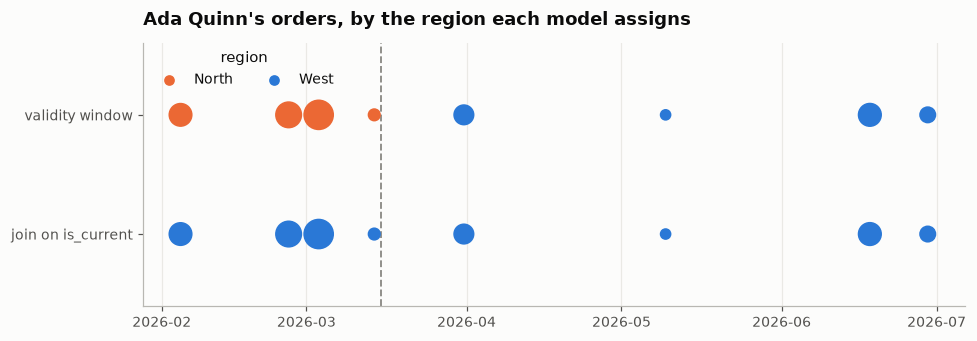

In [10]:
# ============================================================================
# 5.2  One customer who moved
# ----------------------------------------------------------------------------
# In   : baseline, TRUE_LEDGER
# Out  : the example table and chart
# Note : The same orders attributed by the validity window and by
#        is_current.
# ============================================================================
sc = CONFIG["showcase"]
con = duckdb.connect(config={"threads": 1})
load_raw(con)
build_models(con, {**STAGING, **MARTS})
example = con.execute(f'''
    select o.order_id, cast(o.order_ts as varchar) as order_ts,
           cast(sum(l.line_revenue) as decimal(12, 2)) as amount,
           d.region as model_region, cur.region as is_current_region
    from fct_order o
    join dim_customer d on d.customer_sk = o.customer_sk
    join dim_customer cur on cur.customer_id = d.customer_id and cur.is_current
    join fct_order_line l on l.order_id = o.order_id
    where d.customer_id = {sc["customer_id"]}
    group by 1, 2, 4, 5 order by 1''').df()
con.close()
truth = {o["order_id"]: o["true_region"] for o in TRUE_LEDGER["showcase_orders"]}
example["true_region"] = example["order_id"].map(truth)
example["order_ts"] = pd.to_datetime(example["order_ts"])
example["model_ok"] = example["model_region"] == example["true_region"]
example["is_current_ok"] = example["is_current_region"] == example["true_region"]
print(f"{sc['name']} moved {sc['region_from']} -> {sc['region_to']} at {sc['moved_at']}")
display(example[["order_id", "order_ts", "amount", "true_region", "model_region",
                 "is_current_region", "model_ok", "is_current_ok"]])

fig, ax = plt.subplots(figsize=(9, 3.2))
region_colour = {sc["region_from"]: ORANGE, sc["region_to"]: BLUE}
for y, column in ((1, "model_region"), (0, "is_current_region")):
    ax.scatter(example["order_ts"], [y] * len(example), s=example["amount"].astype(float) * 0.5,
               c=[region_colour[r] for r in example[column]], zorder=3)
ax.axvline(pd.Timestamp(sc["moved_at"]), color=GREY, lw=1.2, ls="--", zorder=2)
ax.set_yticks([0, 1], ["join on is_current", "validity window"])
ax.set_ylim(-0.6, 1.6)
style(ax, f"{sc['name']}'s orders, by the region each model assigns", grid="x")
ax.scatter([], [], c=ORANGE, label=sc["region_from"])
ax.scatter([], [], c=BLUE, label=sc["region_to"])
ax.legend(loc="upper left", ncol=2, title="region", bbox_to_anchor=(0, 1.02))
plt.tight_layout()
plt.show()

## 6. The naive version of each trap

Each naive model is the correct SQL with one plausible edit. The edits are listed
in `VARIANTS` (this is the repo's `variants.py`, unchanged), and each one is
applied to a copy of the model text, never to the original.

In [11]:
# ============================================================================
# 6.1  Build the six naive versions
# ----------------------------------------------------------------------------
# In   : variants
# Out  : naive results
# Note : Each naive version is a plausible edit to the correct SQL.
# ============================================================================
JOIN_WINDOW = ("    and o.order_ts >= c.valid_from\n"
               "    and o.order_ts < c.valid_to")
FCT_ORDER = "models/marts/fct_order.sql"
FCT_LINE = "models/marts/fct_order_line.sql"
DIM_CUSTOMER = "models/marts/dim_customer.sql"
STG_LINES = "models/staging/stg_order_lines.sql"
BACKDATE = ("case when version_no = 1 then cast('1900-01-01' as timestamp) "
            "else updated_at end as valid_from")

TYPE1_CUSTOMER = """-- mutation: Type 1. One row per customer holding the latest region.
select
    row_number() over (order by customer_id) as customer_sk,
    customer_id,
    name,
    email,
    region,
    1 as version_no,
    cast('1900-01-01' as timestamp) as valid_from,
    cast('9999-12-31' as timestamp) as valid_to,
    true as is_current
from (
    select
        *,
        row_number() over (partition by customer_id order by updated_at desc) as recency
    from {{ ref('stg_customer_changes') }}
)
where recency = 1
"""

WRONG_GRAIN_LINE = """-- mutation: one row per (order, category) instead of one row per order line.
select
    l.order_id,
    min(l.line_no) as line_no,
    c.customer_sk,
    min(p.product_sk) as product_sk,
    o.order_ts,
    cast(o.order_ts as date) as order_date,
    sum(l.quantity) as quantity,
    sum(l.quantity * l.unit_price - l.discount) as line_revenue
from {{ ref('stg_order_lines') }} as l
inner join {{ ref('stg_orders') }} as o on o.order_id = l.order_id
left join {{ ref('dim_customer') }} as c
    on c.customer_id = o.customer_id
    and o.order_ts >= c.valid_from
    and o.order_ts < c.valid_to
left join {{ ref('dim_product') }} as p on p.product_id = l.product_id
group by l.order_id, c.customer_sk, o.order_ts, p.category
"""


def _replace(path, old, new):
    return {"op": "replace", "path": path, "old": old, "new": new}


def _both_facts(old, new):
    return [_replace(FCT_ORDER, old, new), _replace(FCT_LINE, old, new)]


VARIANTS = [
    {"id": "m01_join_on_is_current", "trap": "1 relocation",
     "title": "Join facts to the customer dimension on is_current",
     "ops": _both_facts(JOIN_WINDOW, "    and c.is_current")},
    {"id": "m02_type1_customer", "trap": "1 relocation",
     "title": "Overwrite the customer region in place (Type 1)",
     "ops": [{"op": "write", "path": DIM_CUSTOMER, "text": TYPE1_CUSTOMER}]},
    {"id": "m03_shipping_on_line_fact", "trap": "2 mixed grain",
     "title": "Put order-level shipping on the line fact and sum it there",
     "ops": [
         _replace(FCT_LINE, "    l.discount,\n",
                  "    l.discount,\n    o.shipping_cost,\n"),
         _replace("models/marts/rpt_shipping_by_region_day.sql",
                  "from {{ ref('fct_order') }} as f",
                  "from {{ ref('fct_order_line') }} as f"),
         _replace("models/marts/rpt_shipping_by_region_day.sql",
                  "count(*) as orders", "count(distinct f.order_id) as orders")]},
    {"id": "m04_drop_dedup", "trap": "3 re-sent delivery",
     "title": "Remove the dedup from stg_order_lines",
     "ops": [_replace(STG_LINES, "where copy_rank = 1", "-- mutation: no filter on copy_rank")]},
    {"id": "m05_inner_join_late_customers", "trap": "4 late-arriving dimension",
     "title": "No back-dating, and inner join facts to the window",
     "ops": [_replace(DIM_CUSTOMER, BACKDATE, "updated_at as valid_from")]
            + _both_facts("left join {{ ref('dim_customer') }} as c",
                          "inner join {{ ref('dim_customer') }} as c")},
    {"id": "m06_no_backdate_left_join", "trap": "4 late-arriving dimension",
     "title": "No back-dating, facts keep the left join",
     "ops": [_replace(DIM_CUSTOMER, BACKDATE, "updated_at as valid_from")]},
    {"id": "m07_inclusive_window_join", "trap": "5 overlapping windows",
     "title": "Join with <= valid_to, so a boundary matches two versions",
     "ops": _both_facts("and o.order_ts < c.valid_to", "and o.order_ts <= c.valid_to")},
    {"id": "m08_dedup_on_wrong_key", "trap": "3 re-sent delivery",
     "title": "Dedup on order_id alone instead of (order_id, line_no)",
     "ops": [_replace(STG_LINES, "partition by order_id, line_no", "partition by order_id")]},
    {"id": "m09_float_money", "trap": "money type",
     "title": "Cast money to DOUBLE in staging",
     "ops": [
         _replace(STG_LINES, "cast(unit_price as decimal(12, 2))", "cast(unit_price as double)"),
         _replace(STG_LINES, "cast(discount as decimal(12, 2))", "cast(discount as double)"),
         _replace("models/staging/stg_orders.sql", "cast(shipping_cost as decimal(12, 2))",
                  "cast(shipping_cost as double)")]},
    {"id": "m10_wrong_grain", "trap": "grain",
     "title": "Collapse order lines to one row per order and category",
     "ops": [{"op": "write", "path": FCT_LINE, "text": WRONG_GRAIN_LINE}]},
    {"id": "m11_stale_is_current", "trap": "SCD2 maintenance",
     "title": "Never clear is_current on superseded versions",
     "ops": [_replace(DIM_CUSTOMER, "next_updated_at is null as is_current",
                      "true as is_current")]},
    {"id": "m12_skip_product_correction", "trap": "Type 1 correction",
     "title": "Ignore the product category corrections",
     "ops": [_replace("models/marts/dim_product.sql",
                      "coalesce(c.corrected_category, p.category) as category",
                      "p.category as category")]},
    {"id": "m13_timezone_shift", "trap": "date derivation",
     "title": "Derive order_date with a 6 hour offset",
     "ops": _both_facts("cast(o.order_ts as date) as order_date",
                        "cast(o.order_ts + interval 6 hour as date) as order_date")},
]

# The realistic wrong answer for each planted trap, in README order.
NAIVE_IDS = ["m01_join_on_is_current", "m02_type1_customer", "m03_shipping_on_line_fact",
             "m04_drop_dedup", "m05_inner_join_late_customers", "m07_inclusive_window_join"]


def by_id(variant_id):
    return next(v for v in VARIANTS if v["id"] == variant_id)


def patch_files(files, ops):
    """Return a copy of {path: text} with the edits applied.

    Every replace must match exactly once. A silent no-op would make a mutation
    look harmless when it never ran, so a miss raises."""
    out = dict(files)
    for op in ops:
        if op["op"] == "write":
            out[op["path"]] = op["text"]
            continue
        text = out[op["path"]]
        found = text.count(op["old"])
        if found != 1:
            raise ValueError(f"{op['path']}: expected 1 match for {op['old']!r}, found {found}")
        out[op["path"]] = text.replace(op["old"], op["new"])
    return out

naive = [run_variant(by_id(i)) for i in NAIVE_IDS]
print("built", len(naive), "naive models")

built 6 naive models


,trap,naive approach,measure,true total,abs error,net error,% of true
0,1 relocation,Join facts to the customer dimension on is_current,revenue,"4,758,558.74","834,154.02",0.00,17.53%
1,1 relocation,Join facts to the customer dimension on is_current,shipping,"62,111.62","7,120.38",0.00,11.46%
2,1 relocation,Overwrite the customer region in place (Type 1),revenue,"4,758,558.74","834,154.02",0.00,17.53%
3,1 relocation,Overwrite the customer region in place (Type 1),shipping,"62,111.62","7,120.38",0.00,11.46%
4,2 mixed grain,Put order-level shipping on the line fact and sum it there,revenue,"4,758,558.74",0.00,0.00,0.00%
5,2 mixed grain,Put order-level shipping on the line fact and sum it there,shipping,"62,111.62","92,163.41","92,163.41",148.38%
6,3 re-sent delivery,Remove the dedup from stg_order_lines,revenue,"4,758,558.74","93,458.45","93,458.45",1.96%
7,4 late-arriving dimension,"No back-dating, and inner join facts to the window",revenue,"4,758,558.74","73,341.63","-73,341.63",1.54%
8,4 late-arriving dimension,"No back-dating, and inner join facts to the window",shipping,"62,111.62",932.51,-932.51,1.50%
9,5 overlapping windows,"Join with <= valid_to, so a boundary matches two versions",revenue,"4,758,558.74","24,485.14","24,485.14",0.51%


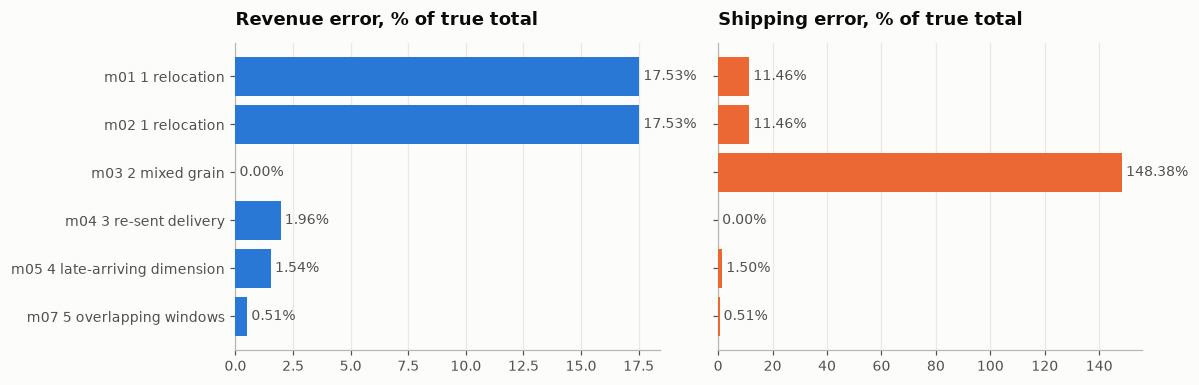

In [12]:
# ============================================================================
# 6.2  Naive against correct, per trap
# ----------------------------------------------------------------------------
# In   : naive results
# Out  : the error table and chart
# Note : Errors are measured against the answer key, to the cent.
# ============================================================================
rows = []
for r in naive:
    for measure in ("revenue", "shipping"):
        s = r["score"][measure]
        if s["exact"] and measure == "shipping":
            continue
        rows.append({"trap": r["trap"], "naive approach": r["title"], "measure": measure,
                     "true total": usd(s["true_total"]), "abs error": usd(s["abs_error"]),
                     "net error": usd(s["net_error"]), "% of true": f"{s['pct_of_true']:.2f}%"})
display(pd.DataFrame(rows))

fig, (a, b) = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
names = [r["id"][:3] + " " + r["trap"] for r in naive]
for ax, measure, colour in ((a, "revenue", BLUE), (b, "shipping", ORANGE)):
    values = [float(r["score"][measure]["pct_of_true"]) for r in naive]
    ax.barh(names, values, color=colour, zorder=3)
    for i, v in enumerate(values):
        ax.text(v + max(values) * 0.01, i, f"{v:.2f}%", va="center", fontsize=9, color=INK2)
    style(ax, f"{measure.capitalize()} error, % of true total", grid="x")
a.invert_yaxis()
plt.tight_layout()
plt.show()

,true,is_current join,error
Central,"956,829.59","954,281.84","-2,547.75"
East,"1,002,410.30","1,002,297.56",-112.74
North,"954,035.80","980,834.05","26,798.25"
South,"910,059.36","912,656.55","2,597.19"
West,"935,223.69","908,488.74","-26,734.95"


revenue in the wrong region: 593,658.28


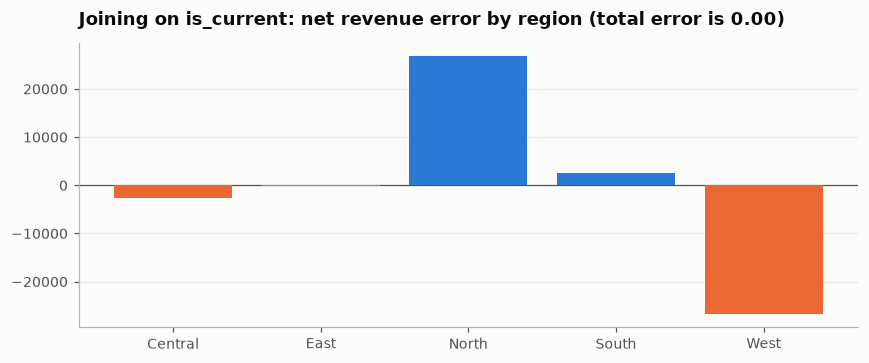

In [13]:
# ============================================================================
# 6.3  Revenue by region when you join on is_current
# ----------------------------------------------------------------------------
# In   : naive results
# Out  : the by-region table and chart
# Note : The total is exact and every region is wrong.
# ============================================================================
m01 = next(r for r in naive if r["id"] == "m01_join_on_is_current")["score"]["revenue"]
regions = sorted(m01["true_by_region"])
table = pd.DataFrame({"true": [m01["true_by_region"][g] for g in regions],
                      "is_current join": [m01["report_by_region"][g] for g in regions],
                      "error": [m01["by_region"][g] for g in regions]}, index=regions)
display(table.map(usd))
print("revenue in the wrong region:", usd(Decimal(TRUE_LEDGER["relocated_revenue_cents"]).scaleb(-2)))

fig, ax = plt.subplots(figsize=(8, 3.4))
errors = [float(m01["by_region"][g]) for g in regions]
ax.bar(regions, errors, color=[ORANGE if e < 0 else BLUE for e in errors], zorder=3)
ax.axhline(0, color=INK2, lw=0.8)
style(ax, "Joining on is_current: net revenue error by region (total error is 0.00)")
plt.tight_layout()
plt.show()

true shipping 62,111.62  summed on the line fact 154,275.03  overstated by 92,163.41 (148.38%)


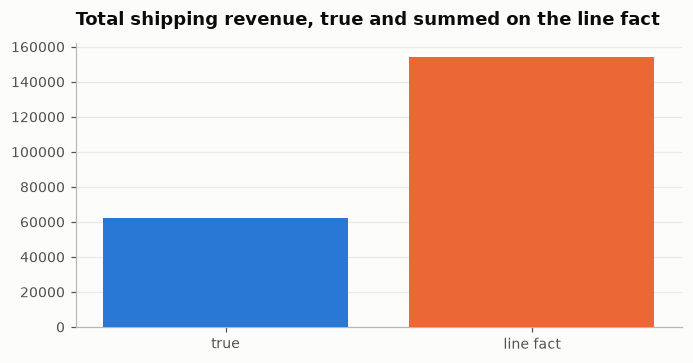

In [14]:
# ============================================================================
# 6.4  Shipping on the line fact
# ----------------------------------------------------------------------------
# In   : naive results
# Out  : the shipping table and chart
# Note : Order-level shipping summed at line grain.
# ============================================================================
m03 = next(r for r in naive if r["id"] == "m03_shipping_on_line_fact")["score"]["shipping"]
print("true shipping", usd(m03["true_total"]), " summed on the line fact",
      usd(m03["report_total"]), " overstated by", usd(m03["net_error"]),
      f"({m03['pct_of_true']:.2f}%)")

fig, ax = plt.subplots(figsize=(6.4, 3.4))
ax.bar(["true", "line fact"], [float(m03["true_total"]), float(m03["report_total"])],
       color=[BLUE, ORANGE], zorder=3)
style(ax, "Total shipping revenue, true and summed on the line fact")
plt.tight_layout()
plt.show()

## 7. The mutation matrix

Now break the correct model thirteen ways, five of them the traps above and
eight more that a reviewer would also call plausible. For each break, run every
test and record which ones fail. A test that only passes proves nothing until you
know a break that makes it fail.

Tests come in three tiers.

* **Generic** tests are the `schema.yml` tests. Uniqueness, not null, accepted values, relationships, and a grain test.
* **Singular** tests are the four business rules from the brief. One current row per customer, facts inside their customer window, line revenue reconciling to staging, shipping reconciling to staging.
* **Added** tests were written after the first matrix showed breaks that nothing caught. Each one closes a named gap.

In [15]:
# ============================================================================
# 7.1  Run the mutation matrix
# ----------------------------------------------------------------------------
# In   : variants, the engine
# Out  : matrix results, the summary table
# Note : 13 breaks, every test, one build each.
# ============================================================================
matrix = [baseline] + [run_variant(v) for v in VARIANTS]
rows = []
for r in matrix[1:]:
    fired = tiers_firing(r)
    rows.append({"id": r["id"][:3], "mutation": r["title"],
                 "G/S/A failing": " / ".join(str(len(fired[t])) for t in TIERS),
                 "first caught by": classify(r), "silent": "SILENT" if is_silent(r) else "",
                 "revenue abs err": usd(r["score"]["revenue"]["abs_error"]),
                 "shipping abs err": usd(r["score"]["shipping"]["abs_error"]),
                 "answer exact": r["score"]["revenue"]["exact"] and r["score"]["shipping"]["exact"]})
display(pd.DataFrame(rows))

,id,mutation,G/S/A failing,first caught by,silent,revenue abs err,shipping abs err,answer exact
0,m01,Join facts to the customer dimension on is_current,0 / 1 / 0,singular only,,"834,154.02","7,120.38",False
1,m02,Overwrite the customer region in place (Type 1),0 / 0 / 1,added only,SILENT,"834,154.02","7,120.38",False
2,m03,Put order-level shipping on the line fact and sum it there,0 / 0 / 1,added only,SILENT,0.00,"92,163.41",False
3,m04,Remove the dedup from stg_order_lines,2 / 0 / 1,generic,,"93,458.45",0.00,False
4,m05,"No back-dating, and inner join facts to the window",0 / 2 / 1,singular only,,"73,341.63",932.51,False
5,m06,"No back-dating, facts keep the left join",4 / 0 / 0,generic,,"146,683.26","1,865.02",False
6,m07,"Join with <= valid_to, so a boundary matches two versions",2 / 3 / 1,generic,,"24,485.14",314.54,False
7,m08,"Dedup on order_id alone instead of (order_id, line_no)",0 / 0 / 1,added only,SILENT,"2,839,187.42",0.00,False
8,m09,Cast money to DOUBLE in staging,0 / 2 / 3,singular only,,0.00,0.00,False
9,m10,Collapse order lines to one row per order and category,0 / 0 / 1,added only,SILENT,0.00,0.00,False


G1  not_null[fct_order.customer_sk]
G2  not_null[fct_order_line.customer_sk]
G3  not_null[rpt_revenue_by_region_category_day.region]
G4  not_null[rpt_shipping_by_region_day.region]
G5  unique[fct_order.order_id]
G6  unique_combination_of_columns[fct_order_line](order_id,line_no)
G7  unique_combination_of_columns[stg_order_lines](order_id,line_no)
S1  assert_fact_inside_customer_window
S2  assert_line_revenue_reconciles_to_staging
S3  assert_one_current_row_per_customer
S4  assert_shipping_reconciles_to_staging
A1  assert_dim_customer_keeps_every_source_version
A2  assert_fact_row_counts_match_staging
A3  assert_product_corrections_applied
A4  assert_report_reconciles_to_facts
A5  assert_staging_keeps_every_distinct_source_line
A6  column_is_decimal[fct_order.shipping_cost]
A7  column_is_decimal[fct_order_line.line_revenue]


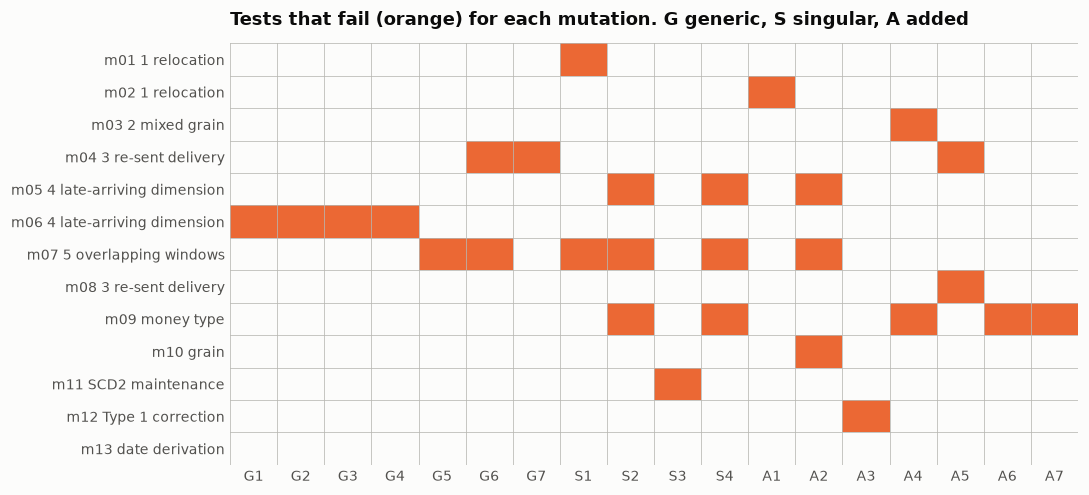

In [16]:
# ============================================================================
# 7.2  Which test fires for which break
# ----------------------------------------------------------------------------
# In   : matrix results
# Out  : the test grid and heatmap
# Note : A test that never fails for any plausible break is not protecting
#        anything.
# ============================================================================
firing = {}
for r in matrix[1:]:
    for t in r["tests"]:
        if t["status"] != "pass":
            firing[t["label"]] = t["tier"]
order = sorted(firing, key=lambda lab: (TIERS.index(firing[lab]), lab))
codes = {lab: f"{firing[lab][0].upper()}{sum(1 for o in order[:order.index(lab) + 1] if firing[o] == firing[lab])}"
         for lab in order}
grid = [[int(any(t["label"] == lab and t["status"] != "pass" for t in r["tests"])) for lab in order]
        for r in matrix[1:]]
for lab in order:
    print(f"{codes[lab]:<4}{lab}")

fig, ax = plt.subplots(figsize=(10, 4.6))
ax.imshow(grid, cmap=mpl.colors.ListedColormap([SURFACE, ORANGE]), aspect="auto")
ax.set_xticks(range(len(order)), [codes[lab] for lab in order])
ax.set_yticks(range(len(grid)), [r["id"][:3] + " " + r["trap"] for r in matrix[1:]])
ax.set_xticks([x - 0.5 for x in range(len(order) + 1)], minor=True)
ax.set_yticks([y - 0.5 for y in range(len(grid) + 1)], minor=True)
ax.grid(which="minor", color=MUTED, lw=0.5)
ax.tick_params(which="both", length=0)
ax.set_title("Tests that fail (orange) for each mutation. G generic, S singular, A added")
for s in ax.spines.values():
    s.set_visible(False)
plt.tight_layout()
plt.show()

{'generic': 3, 'singular only': 4, 'added only': 5, 'nothing': 1} | silent (typical suite passes, answer wrong): 6


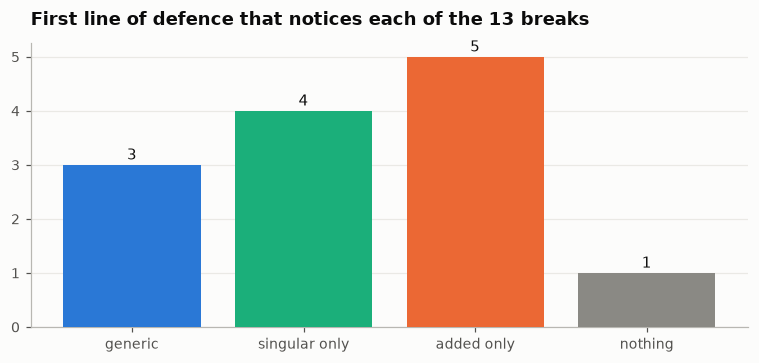

In [17]:
# ============================================================================
# 7.3  Who catches what
# ----------------------------------------------------------------------------
# In   : matrix results
# Out  : the bucket counts and chart
# Note : First line of defence per break.
# ============================================================================
buckets = {k: 0 for k in ("generic", "singular only", "added only", "nothing")}
for r in matrix[1:]:
    buckets[classify(r)] += 1
silent = sum(1 for r in matrix[1:] if is_silent(r))
print(buckets, "| silent (typical suite passes, answer wrong):", silent)

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.bar(list(buckets), list(buckets.values()), color=[BLUE, AQUA, ORANGE, GREY], zorder=3)
for i, v in enumerate(buckets.values()):
    ax.text(i, v + 0.1, str(v), ha="center", fontsize=10)
style(ax, "First line of defence that notices each of the 13 breaks")
plt.tight_layout()
plt.show()

## 8. The numbers this notebook produced

The next cell prints one JSON block. `tests/test_lessons.py` in the repo parses it
from the saved notebook and compares it with the numbers `python run.py break`
writes, using real dbt. If they ever differ, the suite fails.

In [18]:
# ============================================================================
# 8.1  The numbers this notebook produced
# ----------------------------------------------------------------------------
# In   : everything above
# Out  : RESULTS (printed as JSON)
# Note : tests/test_lessons.py compares this block to the numbers run.py
#        writes.
# ============================================================================
def brief(r):
    s = r["score"]
    return {"first_caught_by": classify(r), "silent": is_silent(r),
            "failing": {t["label"]: t["failures"] for t in r["tests"] if t["status"] != "pass"},
            "revenue_abs_error": str(s["revenue"]["abs_error"]), "revenue_net_error": str(s["revenue"]["net_error"]),
            "shipping_abs_error": str(s["shipping"]["abs_error"]), "shipping_net_error": str(s["shipping"]["net_error"]),
            "exact": s["revenue"]["exact"] and s["shipping"]["exact"],
            "rows": r["rows"]}


RESULTS = {"tests_in_suite": len(baseline["tests"]), "buckets": buckets, "silent": silent,
           "variants": {r["id"]: brief(r) for r in matrix}}
print("RESULTS_JSON " + json.dumps(RESULTS, sort_keys=True))

RESULTS_JSON {"buckets": {"added only": 5, "generic": 3, "nothing": 1, "singular only": 4}, "silent": 6, "tests_in_suite": 64, "variants": {"baseline": {"exact": true, "failing": {}, "first_caught_by": "nothing", "revenue_abs_error": "0.00", "revenue_net_error": "0.00", "rows": {"dim_customer": 1950, "dim_product": 400, "fct_order": 12000, "fct_order_line": 29902, "rpt_revenue_by_region_category_day": 5372, "rpt_shipping_by_region_day": 905, "stg_customer_changes": 1950, "stg_order_lines": 29902, "stg_orders": 12000, "stg_products": 400}, "shipping_abs_error": "0.00", "shipping_net_error": "0.00", "silent": false}, "m01_join_on_is_current": {"exact": false, "failing": {"assert_fact_inside_customer_window": 5535}, "first_caught_by": "singular only", "revenue_abs_error": "834154.02", "revenue_net_error": "0.00", "rows": {"dim_customer": 1950, "dim_product": 400, "fct_order": 12000, "fct_order_line": 29902, "rpt_revenue_by_region_category_day": 5376, "rpt_shipping_by_region_day": 905, "st

## 9. What to take away

* **Grain first.** `fct_order_line` has one row per `(order_id, line_no)` and
  `fct_order` has one row per order. The uniqueness tests follow from those two
  sentences, and so does the decision to keep shipping on the order fact.
* **The region question forces the Type 2 dimension.** "Revenue by the region the
  customer was in at the time" cannot be answered from a dimension that only
  knows where the customer is now.
* **Judge a test by what breaks it.** Most of the tests never fire for any of the
  13 breaks. That does not make them wrong, but this matrix gives no evidence
  that they protect anything.
* **Reconciling to a wrong staging model passes.** Dropping the dedup inflates
  staging and the fact together, so the fact still equals staging. The test that
  catches it goes back to the raw table.
* **One break is caught by nothing.** The 6 hour date shift keeps every total,
  count and window intact. Only a comparison with an independent source of truth,
  which is what the answer key is here, shows it.

### What this does not prove

The data is generated, and each trap is planted at a rate chosen to be visible.
Real exports break in ways nobody planted. Thirteen mutations are a sample, not a
census, and the added tests were written after the first matrix, so a clean
second matrix shows they close the gaps found, not that no gaps remain.